# Tutorial about fluopy - Cy5 in dSTORM simulation

Here we outline a simulation procedure for typcial Cy5 fluorophore under dSTORM conditions.

In [1]:
from pprint import pprint

%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

import fluopy
import fluopy.analysis as an
import fluopy.blinking as bl
import fluopy.emissions as em
import fluopy.fcs as fcs_p
import fluopy.figure as fi
import fluopy.fluorophores as fl
import fluopy.formulas as fo
import fluopy.miscellaneous as mi
import fluopy.prediction as pr
import fluopy.simulation as si
import fluopy.transitions as tr

In [2]:
fluopy.__version__

'0.1.0.dev218+g6a7acd3b1.d20250915'

In [3]:
rng = np.random.default_rng(seed=1)

## Define the fluorophore system

In [4]:
fluorophore = fl.Fluorophore(name="cy5_dna", position=[0, 0])
fluorophore_system = fl.FluorophoreSystem(fluorophores=[fluorophore])

In [5]:
pprint(vars(fluorophore_system))

{'count': 1,
 'distances': {},
 'fluorophores': [Fluorophore(identity=0,
                              name='cy5_dna',
                              position=array([0, 0]),
                              constants=FluorophoreData(data_files='cy5_data',
                                                        QUANTUM_YIELD=0.27,
                                                        FLUORESCENCE_LIFETIME=1.7e-09,
                                                        S1_QUENCH_RATE=0,
                                                        ISC_ST_RATE=830000.0,
                                                        ISC_TS_RATE=5000.0,
                                                        RISC_RATE=0,
                                                        STA_EFFICIENCY=0,
                                                        PHOTOBLEACH_T1_RATE=10.0,
                                                        PHOTOBLEACH_T2_RATE=0,
                                                     

## Define the transition set

In [6]:
transitions = fluorophore_system.load_transitions(
    summarize=True,
    irradiance=2,
    wavelength=640,
    bleaching=False,
    energy_transfer=False,
    dstorm=True,
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set = transition_set.remove_energy_transfers()
transition_set.finalize()

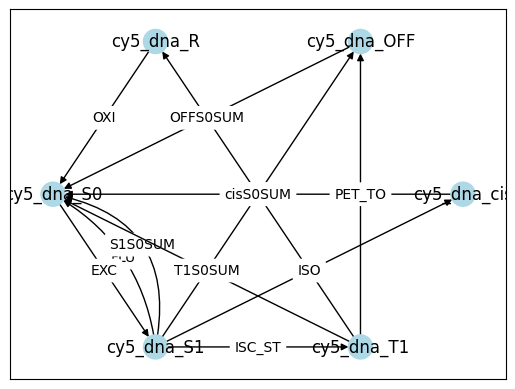

In [7]:
transition_set.plot(graph_type="shell", colors=None, scale=1);

In [8]:
transition_set.transition_df

transition_type abbreviation  \
Fluorophore identity                                                        
cy5_dna     0                      TransitionType.EXCITATION          EXC   
            1            TransitionType.FLUORESCENT_EMISSION          FLU   
            2         TransitionType.INTERSYSTEM_CROSSING_ST       ISC_ST   
            3                   TransitionType.ISOMERIZATION          ISO   
            4                        TransitionType.ADDUCT_T       PET_TO   
            5                        TransitionType.ADDUCT_S       PET_SO   
            6                      TransitionType.RAD_ESCAPE       PET_TR   
            7                       TransitionType.RAD_RELAX          OXI   
            8               TransitionType.S1_S0_TRANSITIONS      S1S0SUM   
            9               TransitionType.T1_S0_TRANSITIONS      T1S0SUM   
            10             TransitionType.CIS_S0_TRANSITIONS     cisS0SUM   
            11             TransitionType.OFF_S0_TRANSITIONS     OFFS0SUM   

                        initial_state      final_state          rate  photon  \
Fluorophore identity                                                           
cy5_dna     0          SingleState.S0   SingleState.S1  5.815700e+06   False   
            1          SingleState.S1   SingleState.S0  1.588235e+08    True   
            2          SingleState.S1   SingleState.T1  8.300000e+05   False   
            3          SingleState.S1  SingleState.cis  4.000000e+06   False   
            4          SingleState.T1  SingleState.OFF  4.383440e+02   False   
            5          SingleState.S1  SingleState.OFF  4.383440e+03   False   
            6          SingleState.T1    SingleState.R  4.383440e+03   False   
            7           SingleState.R   SingleState.S0  1.300000e+03   False   
            8          SingleState.S1   SingleState.S0  4.289652e+08   False   
            9          SingleState.T1   SingleState.S0  4.433440e+05   False   
            10        SingleState.cis   SingleState.S0  4.366202e+04   False   
            11        SingleState.OFF   SingleState.S0  4.866202e-02   False   

                     fluorophore_ids  absorbing  
Fluorophore identity                             
cy5_dna     0                    [0]      False  
            1                    [0]      False  
            2                    [0]      False  
            3                    [0]      False  
            4                    [0]      False  
            5                    [0]      False  
            6                    [0]      False  
            7                    [0]      False  
            8                    [0]      False  
            9                    [0]      False  
            10                   [0]      False  
            11                   [0]      False

## Make a prediction

In [9]:
%%time
prediction = pr.Prediction(transition_set)
prediction

CPU times: total: 15.6 ms
Wall time: 11 ms


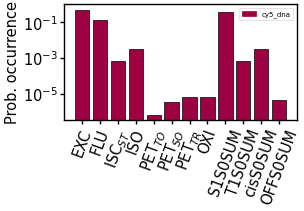

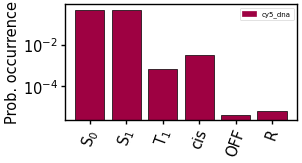

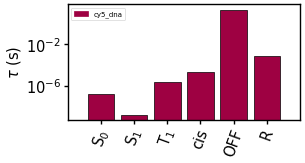

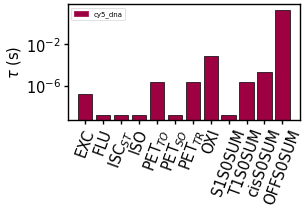

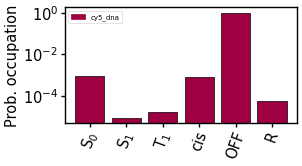

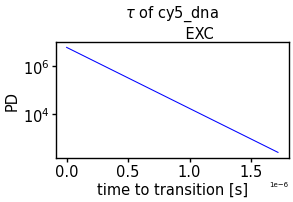

In [10]:
prediction.plot_frequency_transitions(scale=0.5)
prediction.plot_frequency_states(scale=0.5)
prediction.plot_mean_lifetimes(scale=0.5)
prediction.plot_mean_transition_times(scale=0.5)
prediction.plot_state_occupations(scale=0.5)
prediction.plot_transition_time_distributions(
    fluorophore="cy5_dna", transition_id=0, scale=0.5
);

## Run a simulation

In [11]:
simulation = si.Simulation(transition_set)
simulation

In [12]:
%%time
# simulate until it reaches given end_time
simulation.run(start_at=None, size=1e6, end_time=500, seed=rng, use_memmap=None)
mi.print_class(simulation)

Floating point precision error warning:
 The smallest safe increment is 5.68e-14.
 Everything drawn below this number might be rounded to zero
 when approaching the time limit of this simulation.
 Using the highest possible rate which occurs for example in state combination [1]
 gives a probability of 3.37e-05 for a smaller increment to be drawn.


Attributes of <fluopy.simulation.Simulation object at 0x000001D5BAAB3230>:
.................................................................
transition_set = <fluopy.transitions.TransitionSet object at 0x000001D5BA9C7110>
_________________________________________________________________
time_series = array([0.00000000e+00, 1.15167401e-07, 1.1843564....95205381e+02, 5.00000000e+02], shape=(5712133,))
_________________________________________________________________
transition_series = array([0, 8, 0, ..., 1, 0, 5], shape=(5712131,), dtype=uint32)
_________________________________________________________________
state_series = array([[0, 1, 0, ..., 0, 1, 7]], shape=(1, 5712132), dtype=int8)
_________________________________________________________________
memmap_path = None
_________________________________________________________________


CPU times: total: 22.2 s
Wall time: 22.5 s


## Analyze the simulation

In [13]:
analysis = an.Analysis(simulation=simulation)
mi.print_class(analysis)

Attributes of <fluopy.analysis.Analysis object at 0x000001D5BAAB3E00>:
.................................................................
simulation = <fluopy.simulation.Simulation object at 0x000001D5BAAB3230>
_________________________________________________________________
frequency_transitions = array([4.97966696e-01, 1.33388923e-01, 7.1391920... 7.04815768e-04, 3.33833380e-03, 5.60211242e-06])
_________________________________________________________________
frequency_states = {'cy5_dna': array([4.97966609e-01, 4.97966609e-01, 7.1391907...3322e-03,
       5.77717742e-06, 8.75329912e-06])}
_________________________________________________________________
transition_time_distributions = [array([1.15167401e-07, 2.00370096e-07, 1.0292415....95364998e-07, 1.11813222e-07], shape=(2844451,)), array([2.68688345e-09, 1.11625008e-09, 1.3127627...3.94192057e-09, 3.95021971e-09], shape=(761935,)), array([8.07111420e-11, 1.11485205e-09, 3.2127974..., 6.90738489e-09, 2.30653541e-09], shape=(4078

array([[<Axes: title={'center': '$\\tau$ of cy5_dna\n            EXC'}, xlabel='time to transition [s]', ylabel='PD'>]],
      dtype=object)

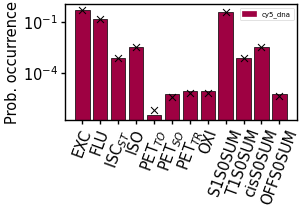

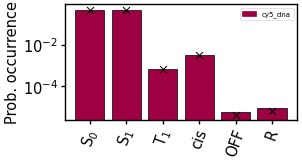

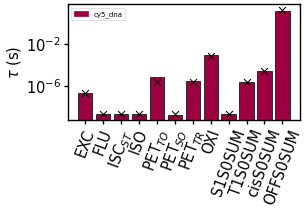

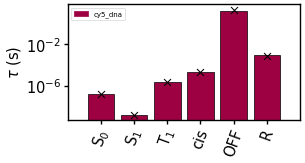

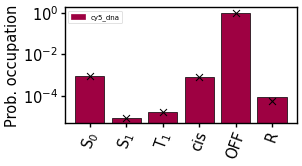

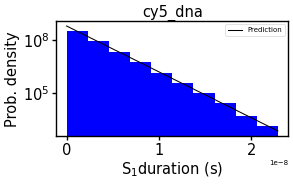

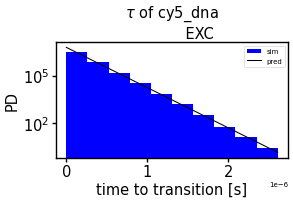

In [14]:
analysis.get_fluorescence_lifetimes(fluorophore="cy5_dna")
analysis.get_emitting_transition_lifetimes(fluorophore="cy5_dna")

analysis.plot_frequency_transitions(scale=0.5, prediction=prediction)
analysis.plot_frequency_states(scale=0.5, prediction=prediction)
analysis.plot_mean_transition_times(scale=0.5, prediction=prediction)
analysis.plot_mean_lifetimes(scale=0.5, prediction=prediction)
analysis.plot_state_occupations(scale=0.5, prediction=prediction)
analysis.plot_lifetime_distributions(
    scale=0.5, prediction=prediction, fluorophore="cy5_dna", state_identity=1
)
analysis.plot_transition_time_distributions(
    scale=0.5, prediction=prediction, fluorophore="cy5_dna", transition_id=0
)

## Simulation of experimentally observable (photons per frames) only

#### Extract photon emission events from simulation

In [15]:
%%time
emissions = em.Emissions(frame_time="5ms", seed=rng, bandpass=(600, 800))
emissions.extract(simulation=simulation)
emissions

CPU times: total: 516 ms
Wall time: 532 ms


#### Simulate photon emission events

Correct for detection efficiency and noise contributions:

In [16]:
emissions.add_photon_collection_objective(p=0.1, seed=rng)  # 1.
emissions.add_quantum_efficiency(p=0.9, seed=rng)  # 3.1.
emissions.add_poisson_noise(
    rate=0.05, seed=rng
)  # 3.2. (dark noise), note the frame time
emissions.add_emccd_gain(emccd_gain=10, seed=rng)  # 4.
emissions.add_gaussian_noise(mean=10, std=1, seed=rng)  # 5. (readout noise)
emissions

emissions = em.Emissions(frame_time="5ms", seed=rng, bandpass=(660, 700))
emissions.extract(simulation=approximation)  

In [17]:
# 2.
# at this point, the bandpass filter was applied
# yet, the effect of photon collection by the objective is missing
# the order is not relevant for two consecutive binomial distributions
# it is more convenient to apply the bandpass first because it needs the
# information about the emitting fluorophore whereas all the other effects are
# roughly wavelength independent
p_photon_collection = fo.calculate_photon_collection_rate(NA=1.45, n1=1.51)
emissions.add_photon_collection_objective(p=p_photon_collection)  # 1.
emissions.add_quantum_efficiency(p=0.9)  # 4.1.
emissions.add_transmittance(p=0.99)  # 3 (depending on number of components of optical
# path, may be applied multiple times)
emissions.add_poisson_noise(rate=0.05)  # 4.2. (dark noise), note the frame time
emissions.add_emccd_gain(emccd_gain=10)  # 5. (+ multiplicative noise)
emissions.add_gaussian_noise(mean=10, std=1, seed=rng)  # 6. (readout noise)
# CIC (spurious noise) neglected since low probability to happen in the pixels of
# interest
emissions.apply_threshold(threshold=100)  # 7 (thresholding)

array([[<Axes: xlabel='Time (s)', ylabel='$\\frac{photons}{frame}$'>]],
      dtype=object)

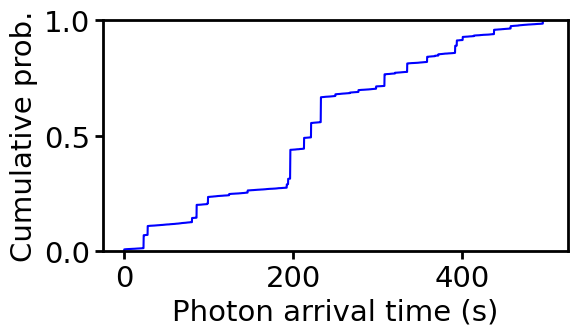

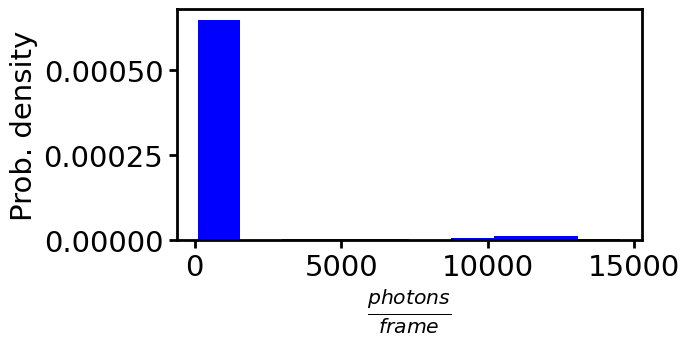

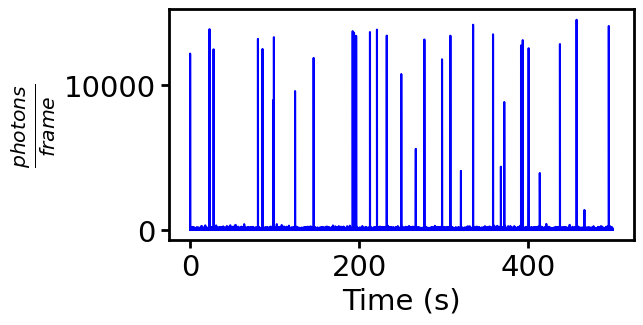

In [18]:
emissions.plot_cumulative_events(scale=1)
emissions.plot_histogram(scale=1)
emissions.plot_time_series(scale=1)

# to save the time_series and time_points
# emissions.save(path='', name_extension='test')

# to load time_series and time_points
# emissions.load(path='', name_extension='test')

## Simulation of pulsed excitation

In [19]:
%%time
emissions_tcspc = em.Emissions(frame_time="1ms", seed=rng, bandpass=None)
lifetimes_DA, lifetimes_D, lifetimes_all = emissions_tcspc.tcspc(
    transition_set=transition_set,
    number_pulses=5e5,
    pulse_duration=1e-11,
    time_between_pulses=1e-7,
    excitation_rates={"cy5_dna": 1e11},
    size=1e5,
    store_time_points=True,
    # details = True
)

the last frame (of index 0.05) has 1.00e+00 times the pulses of other frames.


CPU times: total: 22.8 s
Wall time: 24.1 s


array([[<Axes: xlabel='Time (s)', ylabel='$\\frac{photons}{frame}$'>]],
      dtype=object)

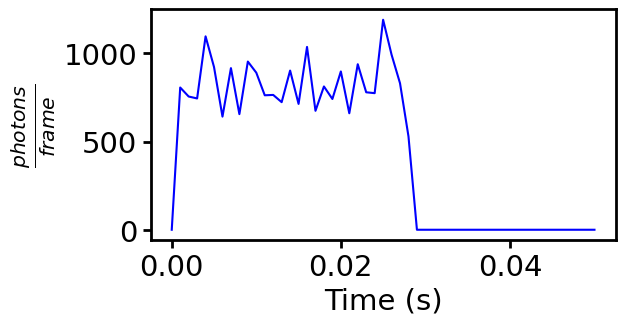

In [20]:
emissions_tcspc.plot_time_series()

array([[<Axes: xlabel='Lifetime (s)', ylabel='PD'>]], dtype=object)

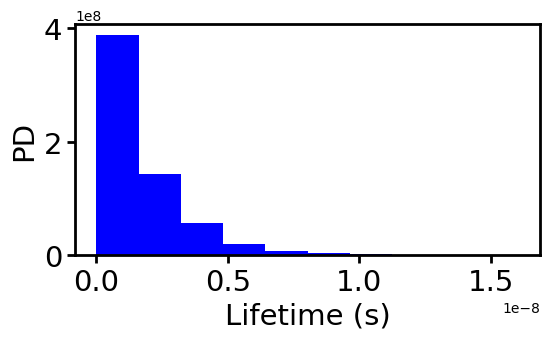

In [21]:
fi.universal_figure(
    type_="hist", data=lifetimes_all, ylabel="PD", density=True, xlabel="Lifetime (s)"
)

## Fluorescence correlation spectroscopy

Observed fluorescence emission events can be analyzed by a correlation analysis.

In [22]:
fcs = fcs_p.FCS(emissions)
list(vars(fcs).keys())

['emissions', 'autocorrelation', 'tau']

### Autocorrelation of time points

In [23]:
%%time
fcs.autocorrelate_time_points(
    exp_min=-20, exp_max=-6, points_per_base=4, base=4, normalize=True
)

CPU times: total: 4.34 s
Wall time: 4.58 s


Attributes of <fluopy.fcs.FCS object at 0x000001D5BAAB2660>:
.................................................................
emissions = <fluopy.emissions.Emissions object at 0x000001D5BAAB30E0>
_________________________________________________________________
autocorrelation = array([   0.        ,    0.        ,    0.      ...89,  520.44977266,  520.89702054,  521.04181879])
_________________________________________________________________
tau = array([1.09785722e-12, 1.55260457e-12, 2.1957144... 1.04193529e-04, 1.47351902e-04, 2.08387058e-04])
_________________________________________________________________




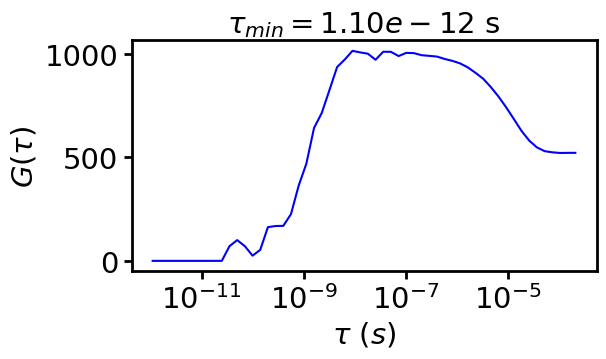

In [24]:
mi.print_class(fcs)
fcs.plot(normalize_to=None, unit="s", scale=1);

### Autocorrelation of time series

In [25]:
fcs.autocorrelate_time_series(log=True, m=4, normalize=True)

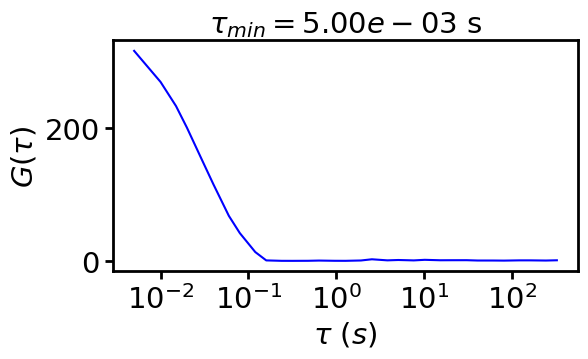

In [26]:
fcs.plot(normalize_to=None, unit="s", scale=1);

In [27]:
# some fcs fits are available:
# fcs_predict = fcs_p.fit_dark(tau, dark_lifetime, dark_occupation)
# fcs_predict = fcs_p.fit_antibunching(tau, excitation_rate, s1_lifetime)
# fcs_predict = fcs_p.fit_triplet_cis(tau, k_isc, k_T, k_01, k_10, k_iso, k_biso_eff)

## Antibunching

Alternatively, you can focus on fast time scales in a linear scale and observe antibunching.

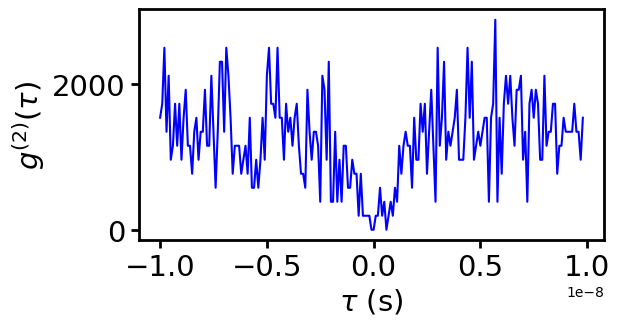

In [28]:
# sensible to tau_max and bin_width, see coincidence notebook
hist, bins = fcs_p.coincidence(
    emissions.event_time_points[: int(2e5)], tau_max=1e-8, bin_width=1e-10, seed=rng
)
fi.universal_figure(
    type_="line",
    data=[bins[:-2], hist],
    xlabel=r"$\tau$ (s)",
    ylabel=r"$g^{(2)}(\tau)$",
    scale=1,
);

## Blinking

### Emissions from a short simulation

We limit the dataset to 2000 frames for illustration purposes.

In [61]:
%%time
emissions = em.Emissions(frame_time="10ms", seed=rng, bandpass=None)
emissions.simulate(
    transition_set=transition_set, store_time_points=False, frames=10_000
)
emissions

CPU times: total: 1.52 s
Wall time: 1.52 s


In [62]:
threshold: int = 1000

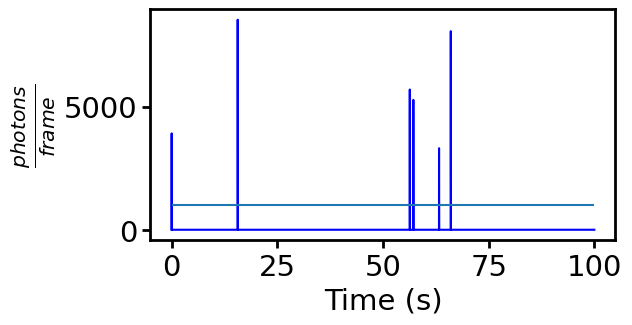

In [63]:
emissions.plot_time_series(scale=1)
plt.hlines(threshold, xmin=0, xmax=100)

In [45]:
blinks = bl.Blinking(emissions, threshold=threshold)
blinks

In [46]:
mi.print_class(blinks)

Attributes of <fluopy.blinking.Blinking object at 0x000001D5CC1E1450>:
.................................................................
emissions = <fluopy.emissions.Emissions object at 0x000001D5C7312F90>
_________________________________________________________________
on_periods = array([ 4,  8,  3,  5,  4, 11])
_________________________________________________________________
off_periods = array([2710,  405,  763,  682, 4861])
_________________________________________________________________
on_periods_frames = array([   1, 2715, 3128, 3894, 4581, 9446])
_________________________________________________________________
off_periods_frames = array([   5, 2723, 3131, 3899, 4585])
_________________________________________________________________




array([[<Axes: xlabel='identity', ylabel='consecutive ON frames'>]],
      dtype=object)

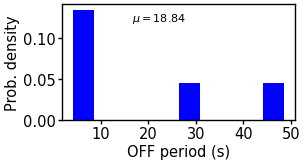

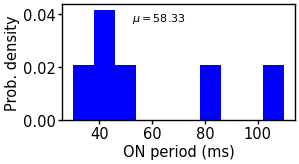

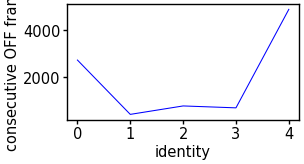

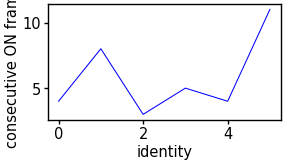

In [47]:
# plot a histogram of OFF times
blinks.plot(
    mode="off_histogram", density=True, display_mean=True, as_time="s", scale=0.5
)

# plot a histogram of ON times
blinks.plot(
    mode="on_histogram", density=True, display_mean=True, as_time="ms", scale=0.5
)

# plot a time series of OFF times
blinks.plot(mode="off_frame_series", scale=0.5)

# plot a time series of ON times
blinks.plot(mode="on_frame_series", scale=0.5)

array([[<Axes: title={'center': 'analytical OFF'}, xlabel='time [s]'>]],
      dtype=object)

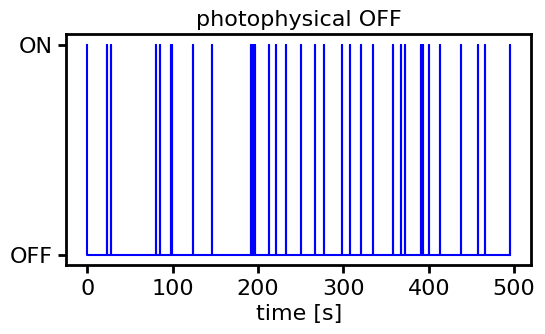

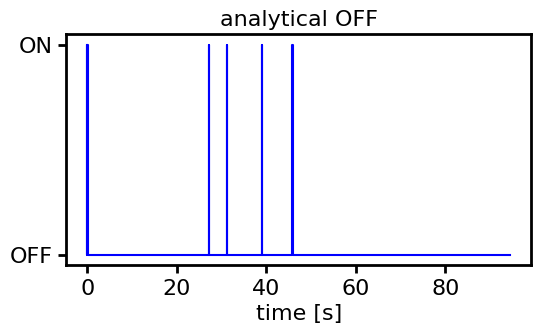

In [48]:
# to get information of the photophysical (not analytical) OFF of each fluorophore, use
on_off_times_photophys, on_off_values_photophys = bl.get_off_statistics(
    simulation=simulation, index=0
)

# to get the analytical OFF statistics as the same view, use
on_off_times_analytic, on_off_values_analytic = bl.get_analytical_off_statistics(
    off_frames=blinks.off_periods_frames,
    off_periods=blinks.off_periods,
    on_frames=blinks.on_periods_frames,
    frame_time=blinks.emissions.parameters["frame_time"],
)

# plot the photophysical OFF statistics
bl.plot_off_statistics(
    on_off_times_photophys,
    on_off_values_photophys,
    scale=1,
    title="photophysical OFF",
)
# plot the analytical OFF statistics (no differentiation between fluorophores)
bl.plot_off_statistics(
    on_off_times_analytic, on_off_values_analytic, scale=1, title="analytical OFF"
)

### Emissions from the long simulation

Get more detailed information from a complete simulation:

In [49]:
%%time
emissions = em.Emissions(frame_time="10ms", seed=rng, bandpass=None)
emissions.extract(simulation=simulation)
emissions

CPU times: total: 438 ms
Wall time: 570 ms


In [50]:
blinks = bl.Blinking(emissions, threshold=threshold)
blinks

In [51]:
mi.print_class(blinks)

Attributes of <fluopy.blinking.Blinking object at 0x000001D5C7140180>:
.................................................................
emissions = <fluopy.emissions.Emissions object at 0x000001D5BCE46690>
_________________________________________________________________
on_periods = array([ 1,  9,  6,  3,  7,  1,  4,  2,  2,  3,  ...  2,  5,  3,  1,  1,  4,  3,  2,  1,  3,  2,  2])
_________________________________________________________________
off_periods = array([2288,  473, 5242,  538, 1277,   62, 2500,...  397, 1981,  201,  692, 1317, 2383, 1966, 3808])
_________________________________________________________________
on_periods_frames = array([    1,  2290,  2772,  8020,  8561,  9845,...39343,
       40038, 41357, 43741, 45710, 49520])
_________________________________________________________________
off_periods_frames = array([    2,  2299,  2778,  8023,  8568,  9846,...39142, 39346,
       40040, 41358, 43744, 45712])
_________________________________________________________

array([[<Axes: xlabel='identity', ylabel='consecutive ON frames'>]],
      dtype=object)

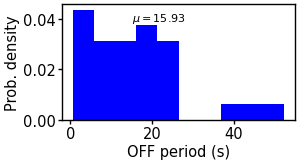

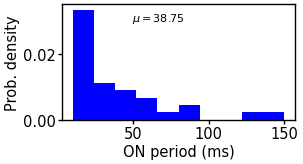

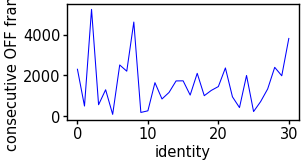

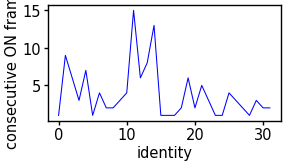

In [52]:
# plot a histogram of OFF times
blinks.plot(
    mode="off_histogram", density=True, display_mean=True, as_time="s", scale=0.5
)

# plot a histogram of ON times
blinks.plot(
    mode="on_histogram", density=True, display_mean=True, as_time="ms", scale=0.5
)

# plot a time series of OFF times
blinks.plot(mode="off_frame_series", scale=0.5)

# plot a time series of ON times
blinks.plot(mode="on_frame_series", scale=0.5)

array([[<Axes: title={'center': 'analytical OFF'}, xlabel='time [s]'>]],
      dtype=object)

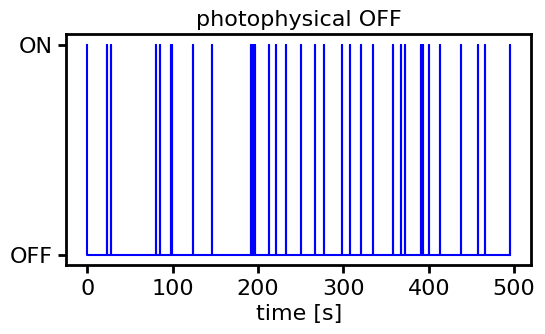

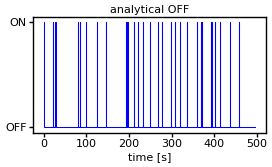

In [53]:
# to get information of the photophysical (not analytical) OFF of each fluorophore, use
on_off_times_photophys, on_off_values_photophys = bl.get_off_statistics(
    simulation=simulation, index=0
)

# to get the analytical OFF statistics as the same view, use
on_off_times_analytic, on_off_values_analytic = bl.get_analytical_off_statistics(
    off_frames=blinks.off_periods_frames,
    off_periods=blinks.off_periods,
    on_frames=blinks.on_periods_frames,
    frame_time=blinks.emissions.parameters["frame_time"],
)

# plot the photophysical OFF statistics
bl.plot_off_statistics(
    on_off_times_photophys,
    on_off_values_photophys,
    scale=1,
    title="photophysical OFF",
)
# plot the analytical OFF statistics (no differentiation between fluorophores)
bl.plot_off_statistics(
    on_off_times_analytic, on_off_values_analytic, scale=0.5, title="analytical OFF"
)